In [19]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import mplfinance as mpf
import ta
import matplotlib.pyplot as plt

# Database credentials
db_config = {
    'host': 'localhost',
    'user': 'root',
    'password': 'Tamir4578',
    'database': 'portalblog_dev'
}

table_name = 'analyzed_data'
timestamp_col = 'time'
open_col = 'open'
high_col = 'high'
low_col = 'low'
close_col = 'close'

# Create database connection string
db_connection_str = 'mysql+pymysql://{user}:{password}@{host}/{database}'.format(**db_config)
db_connection = create_engine(db_connection_str)
def fetch_data_from_db(window_size=500, start_date=None, end_date=None):
    query = f'SELECT * FROM (SELECT * FROM {table_name} ORDER BY {timestamp_col} DESC LIMIT {window_size}) AS recent_data'
    if start_date and end_date:
        query = f'SELECT * FROM (SELECT * FROM {table_name} WHERE {timestamp_col} BETWEEN "{start_date}" AND "{end_date}" ORDER BY {timestamp_col} DESC LIMIT {window_size}) AS recent_data'
    query += f' ORDER BY {timestamp_col} ASC'
    df = pd.read_sql(query, db_connection)
    # Convert the 'time' column to datetime
    df['time'] = pd.to_datetime(df['time'])

    # Set the 'time' column as the index
    df.set_index('time', inplace=True)
    return df
# df = pd.read_sql(query, db_connection)
df = fetch_data_from_db()
df.head()

,id,open,high,low,close,volume,resistance,support,macd,macd_signal,...,rsi_trade,stochastic_trade,channel_trade,bb_upper,bb_middle,bb_lower,bb_trend,bb_signal,near_bb_support,near_bb_resistance
time,,,,,,,,,,,,,,,,,,,,,
2025-01-21 14:00:00,492,3309.69,3335.44,3279.09,3289.41,46772.6,None,None,None,None,...,wait,wait,wait,3345.15,3278.17,3211.20,sideways,wait,NaN,3335.44
2025-01-21 15:00:00,493,3289.42,3302.09,3265.11,3295.10,27063.4,None,None,None,None,...,wait,wait,wait,3335.94,3275.75,3215.56,sideways,wait,NaN,NaN
2025-01-21 16:00:00,494,3295.10,3349.17,3290.50,3313.85,34589.3,None,None,None,None,...,wait,wait,wait,3334.69,3275.43,3216.18,sideways,wait,NaN,NaN
2025-01-21 17:00:00,495,3313.85,3356.59,3307.81,3351.00,20466.4,None,None,None,None,...,wait,wait,wait,3346.92,3278.74,3210.55,sideways,wait,NaN,3356.59
2025-01-21 18:00:00,496,3351.00,3368.00,3330.74,3345.76,21973.6,None,None,None,None,...,wait,sell,wait,3352.58,3280.10,3207.62,sideways,wait,NaN,NaN


# Testing tactic for combination of BB and OSCI.

In [ ]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['stochastic_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['stochastic_trade'] == 'sell' else None, axis=1)
osci_bb_buy_count = df['osci_bb_buy'].count()
osci_bb_sell_count = df['osci_bb_sell'].count()

print(f"osci_bb_buy count: {osci_bb_buy_count}")
print(f"osci_bb_sell count: {osci_bb_sell_count}")

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

# Testing the combination of BB and RSI

osci_bb_buy count: 9
osci_bb_sell count: 10


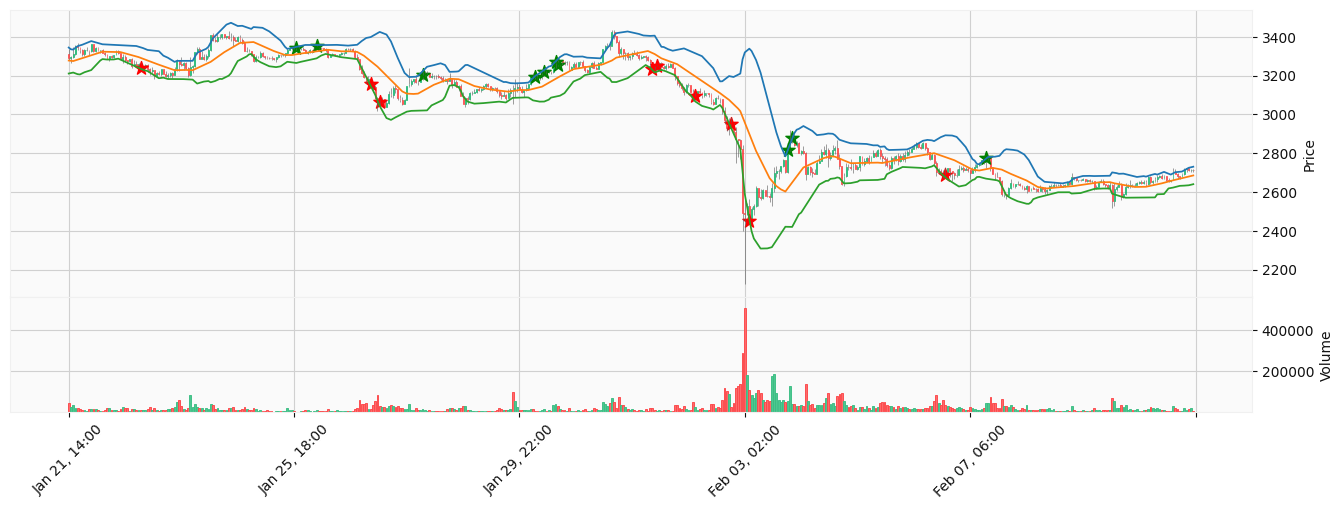

In [21]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)
osci_bb_buy_count = df['osci_bb_buy'].count()
osci_bb_sell_count = df['osci_bb_sell'].count()

print(f"osci_bb_buy count: {osci_bb_buy_count}")
print(f"osci_bb_sell count: {osci_bb_sell_count}")

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

Testing combination of BB and RSI and OSCI

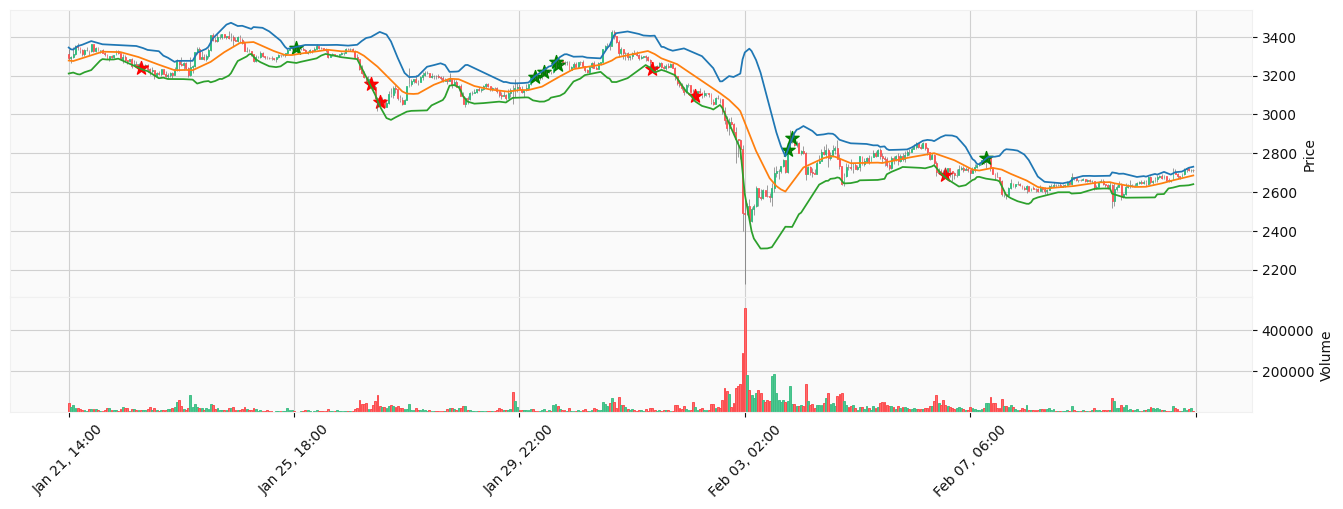

In [38]:
df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['stochastic_trade'] == 'buy' and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['stochastic_trade'] == 'sell' and row['rsi_trade'] == 'sell' else None, axis=1)

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands and buy/sell signals
mpf.plot(df, type='candle', addplot=[bbands, buy_signals, sell_signals], volume=True, style='yahoo', figratio=(3, 1))

In [4]:
import numpy as np

# ============ calculate slope of bb_lower ============
def bb_lower_slope(df):
    # Select the last 4 points of data
    last_points = df['bb_lower'].tail(4)
    # Calculate the slope of the 'bb_lower' line
    x = np.arange(len(last_points))
    y = last_points.values
    slope, _ = np.polyfit(x, y, 1)
    # Convert slope to degrees
    slope_in_degrees = np.degrees(np.arctan(slope))
    return slope, slope_in_degrees

slope, degree = bb_lower_slope(df)
degree
slope

2.7379999999997615

Test with trend reversal detection by candlestick

angle: 69.93628513053625


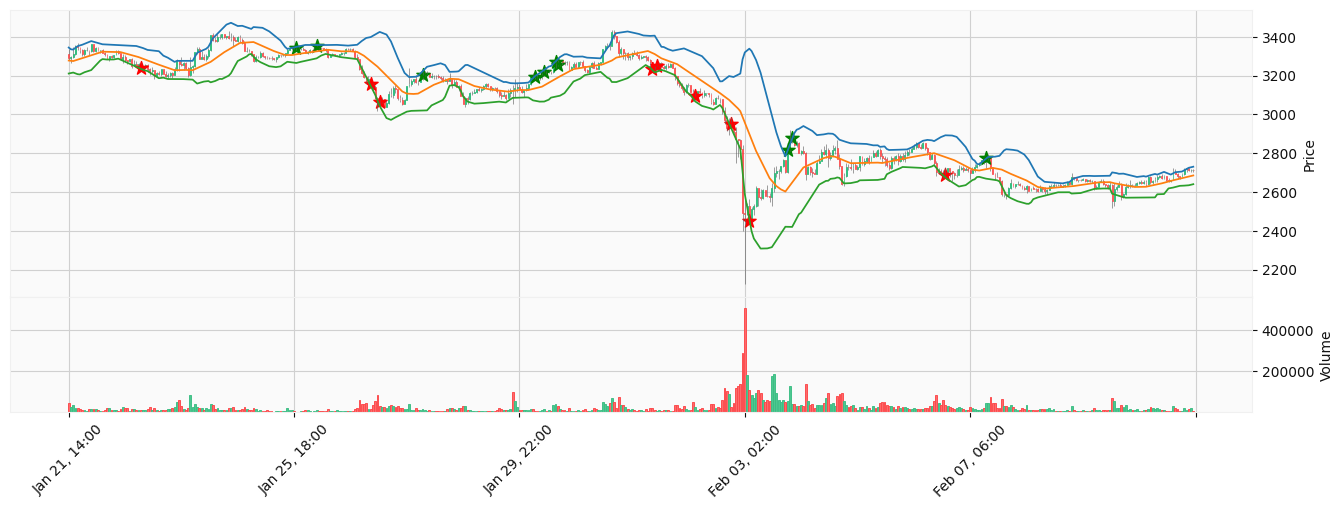

bullish reversal count: 9
bearish reversal count: 496
time
2025-01-21 14:00:00   NaN
2025-01-21 15:00:00   NaN
2025-01-21 16:00:00   NaN
2025-01-21 17:00:00   NaN
2025-01-21 18:00:00   NaN
                       ..
2025-02-11 05:00:00   NaN
2025-02-11 06:00:00   NaN
2025-02-11 07:00:00   NaN
2025-02-11 08:00:00   NaN
2025-02-11 09:00:00   NaN
Name: bullish_reversal, Length: 500, dtype: float64


In [ ]:
import numpy as np

# ============ calculate slope of bb_lower ============
def bb_lower_slope(df):
    # Select the last 4 points of data
    last_points = df['bb_lower'].tail(4)
    # Calculate the slope of the 'bb_lower' line
    x = np.arange(len(last_points))
    y = last_points.values
    slope, _ = np.polyfit(x, y, 1)
    # Convert slope to degrees
    slope_in_degrees = np.degrees(np.arctan(slope))
    return slope, slope_in_degrees

# =========== detect support and resistance levels ===========
def support_resistance(df):
    df['ath'] = df['high'].rolling(window=len(df), min_periods=1).max().shift(1)
    df['atl'] = df['low'].rolling(window=len(df), min_periods=1).min().shift(1)
    return df

df = support_resistance(df)
df['ath'] = df.apply(lambda row: row['close'] if pd.notnull(row['ath']) and pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['atl'] = df.apply(lambda row: row['close'] if pd.notnull(row['atl']) and pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)

# ===================================================================================================
def bb_reversal(df, window=4):
    df['bullish_reversal'] = None
    df['bearish_reversal'] = None
    
    for i in range(window, len(df)):
        window_df = df.iloc[i-window:i]
        # Detect bullish reversal
        if (window_df['close'].iloc[-1] > window_df['open'].iloc[-1] and 
            window_df['close'].iloc[-1] > window_df['close'].iloc[-2] and 
            window_df['close'].iloc[-2] < window_df['close'].iloc[-3]):
            df.at[window_df.index[-1], 'bullish_reversal'] = window_df['close'].iloc[-1]
        else:
            df.at[window_df.index[-1], 'bullish_reversal'] = 0
        
        # Detect bearish reversal
        if (window_df['close'].iloc[-1] < window_df['open'].iloc[-1] and 
            window_df['close'].iloc[-1] < window_df['close'].iloc[-2] and 
            window_df['close'].iloc[-2] > window_df['close'].iloc[-3]):
            df.at[window_df.index[-1], 'bearish_reversal'] = window_df['close'].iloc[-1]
        else:
            df.at[window_df.index[-1], 'bearish_reversal'] = 0
    return df

df['osci_bb_buy'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_support']) and row['rsi_trade'] == 'buy' else None, axis=1)
df['osci_bb_sell'] = df.apply(lambda row: row['close'] if pd.notnull(row['near_bb_resistance']) and row['rsi_trade'] == 'sell' else None, axis=1)

# ========= if BB buy and RSI buy ==========
# If price is near the Bollinger Bands support and the RSI is in the buy zone, then check for bullish reversal
if df['osci_bb_buy'].notnull().any():
    # df = bb_reversal(df)
    slope, angle = bb_lower_slope(df)
    print(f"angle: {angle}")
    # Herev osci_bb_buy deer utga baival 'bb_lower'-iin slope-g shalgana
    if slope > 0 and angle > 0:
        bullish_reversal_signals = mpf.make_addplot(df['osci_bb_buy'].replace(0, np.nan), type='scatter', markersize=100, marker='*', color='red' )
#  If price is near Boillinger Bands resistance and the RSI is in the sell zone, then check for bearish reversal
if df['osci_bb_sell'].notnull().any():
    # df = bb_reversal(df)
    slope, angle = bb_lower_slope(df)    
    # Herev osci_bb_buy deer utga baival 'bb_lower'-iin slope-g shalgana
    if angle > 60:
        bearish_reversal_signals = mpf.make_addplot(df['osci_bb_sell'].replace(0, np.nan), type='scatter', markersize=100, marker='*', color='green')

# Define the Bollinger Bands
bbands = mpf.make_addplot(df[['bb_upper', 'bb_middle', 'bb_lower']])

# Define the buy and sell signals
# buy_signals = mpf.make_addplot(df['osci_bb_buy'], type='scatter', markersize=100, marker='*', color='red')
# sell_signals = mpf.make_addplot(df['osci_bb_sell'], type='scatter', markersize=100, marker='*', color='green')

# Plot the candlestick chart with Bollinger Bands, buy/sell signals, and reversal signals
mpf.plot(df, type='candle', addplot=[bbands, bullish_reversal_signals, bearish_reversal_signals], volume=True, style='yahoo', figratio=(3, 1))

bullish_reversal_signals = df['bullish_reversal'].count()
bearish_reversal_signals = df['bearish_reversal'].count()

print(f"bullish reversal count: {bullish_reversal_signals}")
print(f"bearish reversal count: {bearish_reversal_signals}")
print(df['bullish_reversal'])

# ===================================================================================================


SUPPORT and RESISTANCE

In [23]:
import pandas as pd
# df = pd.read_csv("EURUSD_Candlestick_4_Hour_ASK_05.05.2003-16.10.2021.csv")
# df.columns=['time', 'open', 'high', 'low', 'close', 'volume']
#Check if NA values are in data
df=df[df['volume']!=0]
df.reset_index(drop=True, inplace=True)
df.isna().sum()
df.head(10)

,id,open,high,low,close,volume,resistance,support,macd,macd_signal,...,channel_trade,bb_upper,bb_middle,bb_lower,bb_trend,bb_signal,near_bb_support,near_bb_resistance,osci_bb_buy,osci_bb_sell
0,492,3309.69,3335.44,3279.09,3289.41,46772.60,None,None,None,None,...,wait,3345.15,3278.17,3211.20,sideways,wait,NaN,3335.44,NaN,NaN
1,493,3289.42,3302.09,3265.11,3295.10,27063.40,None,None,None,None,...,wait,3335.94,3275.75,3215.56,sideways,wait,NaN,NaN,NaN,NaN
2,494,3295.10,3349.17,3290.50,3313.85,34589.30,None,None,None,None,...,wait,3334.69,3275.43,3216.18,sideways,wait,NaN,NaN,NaN,NaN
3,495,3313.85,3356.59,3307.81,3351.00,20466.40,None,None,None,None,...,wait,3346.92,3278.74,3210.55,sideways,wait,NaN,3356.59,NaN,NaN
4,496,3351.00,3368.00,3330.74,3345.76,21973.60,None,None,None,None,...,wait,3352.58,3280.10,3207.62,sideways,wait,NaN,NaN,NaN,NaN
5,497,3345.75,3346.63,3318.00,3332.16,14995.40,None,None,None,None,...,wait,3358.64,3282.51,3206.37,sideways,wait,NaN,NaN,NaN,NaN
6,498,3332.16,3339.49,3304.01,3314.39,11131.50,None,None,None,None,...,wait,3359.54,3286.88,3214.23,sideways,wait,NaN,NaN,NaN,NaN
7,499,3314.39,3336.50,3302.03,3331.90,12215.40,None,None,None,None,...,wait,3364.15,3290.95,3217.74,sideways,wait,NaN,NaN,NaN,NaN
8,500,3331.90,3347.12,3326.70,3333.74,8771.23,None,None,None,None,...,wait,3368.59,3294.74,3220.88,sideways,wait,NaN,NaN,NaN,NaN
9,501,3333.75,3334.89,3308.11,3327.54,15981.20,None,None,None,None,...,wait,3371.60,3297.98,3224.37,sideways,wait,NaN,NaN,NaN,NaN


In [24]:
l = len(df)
l

500

In [32]:
dfpl = df[100:400]
import plotly.graph_objects as go
from datetime import datetime

fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [30]:
import numpy as np
from matplotlib import pyplot
backcandles= 50
wind = 5

candleid = 8800

maxim = np.array([])
minim = np.array([])
xxmin = np.array([])
xxmax = np.array([])
for i in range(candleid-backcandles, candleid+1, wind):
    minim = np.append(minim, df.low.iloc[i:i+wind].min())
    xxmin = np.append(xxmin, df.low.iloc[i:i+wind].idxmin())
for i in range(candleid-backcandles, candleid+1, wind):
    maxim = np.append(maxim, df.high.loc[i:i+wind].max())
    xxmax = np.append(xxmax, df.high.iloc[i:i+wind].idxmax())
slmin, intercmin = np.polyfit(xxmin, minim,1)
slmax, intercmax = np.polyfit(xxmax, maxim,1)

dfpl = df[candleid-backcandles:candleid+backcandles]
fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])
fig.add_trace(go.Scatter(x=xxmin, y=slmin*xxmin + intercmin, mode='lines', name='min slope'))
fig.add_trace(go.Scatter(x=xxmax, y=slmax*xxmax + intercmax, mode='lines', name='max slope'))

ValueError: attempt to get argmin of an empty sequence

In [ ]:
dfpl = df[candleid-wind-backcandles:candleid+backcandles]
import plotly.graph_objects as go
from datetime import datetime

fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])

#-------------------------------------------------------------------------
# Fitting intercepts to meet highest or lowest candle point in time slice
adjintercmin = df.low.loc[candleid-backcandles:candleid].min() - slmin*df.low.iloc[candleid-backcandles:candleid].idxmin()
adjintercmax = df.high.loc[candleid-backcandles:candleid].max() - slmax*df.high.iloc[candleid-backcandles:candleid].idxmax()
fig.add_trace(go.Scatter(x=xxmin, y=slmin*xxmin + adjintercmin, mode='lines', name='min slope'))
fig.add_trace(go.Scatter(x=xxmax, y=slmax*xxmax + adjintercmax, mode='lines', name='max slope'))
fig.show()

In [ ]:
dfpl = df[candleid-wind-backcandles:candleid+backcandles]
import plotly.graph_objects as go
from datetime import datetime

fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])

#-------------------------------------------------------------------------
# Fitting intercepts to wrap price candles
adjintercmax = (df.high.iloc[xxmax] - slmax*xxmax).max()
adjintercmin = (df.low.iloc[xxmin] - slmin*xxmin).min()
fig.add_trace(go.Scatter(x=xxmin, y=slmin*xxmin + adjintercmin, mode='lines', name='min slope'))
fig.add_trace(go.Scatter(x=xxmax, y=slmax*xxmax + adjintercmax, mode='lines', name='max slope'))
fig.show()

backcandles time window more dynamic

In [ ]:
import numpy as np
from matplotlib import pyplot
backcandles= 40 # 6*8
brange = 10 # backcandles//4 #should be less than backcandles
wind = 6

candleid = 5000

optbackcandles= backcandles
sldiff = 10000

for r1 in range(backcandles-brange, backcandles+brange):
    maxim = np.array([])
    minim = np.array([])
    xxmin = np.array([])
    xxmax = np.array([])
    for i in range(candleid-r1, candleid+1, wind):
        minim = np.append(minim, df.low.iloc[i:i+wind].min())
        xxmin = np.append(xxmin, df.low.iloc[i:i+wind].idxmin())
    for i in range(candleid-r1, candleid+1, wind):
        maxim = np.append(maxim, df.high.loc[i:i+wind].max())
        xxmax = np.append(xxmax, df.high.iloc[i:i+wind].idxmax())
    slmin, intercmin = np.polyfit(xxmin, minim,1)
    slmax, intercmax = np.polyfit(xxmax, maxim,1)

    if(abs(slmin-slmax)<sldiff):
        sldiff = abs(slmin-slmax)
        optbackcandles=r1
        slminopt = slmin
        slmaxopt = slmax
        intercminopt = intercmin
        intercmaxopt = intercmax
        maximopt = maxim.copy()
        minimopt = minim.copy()
        xxminopt = xxmin.copy()
        xxmaxopt = xxmax.copy()

        print(optbackcandles)
dfpl = df[candleid-wind-optbackcandles-backcandles:candleid+optbackcandles]
fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])

adjintercmax = (df.high.iloc[xxmaxopt] - slmaxopt*xxmaxopt).max()
adjintercmin = (df.low.iloc[xxminopt] - slminopt*xxminopt).min()
fig.add_trace(go.Scatter(x=xxminopt, y=slminopt*xxminopt + adjintercmin, mode='lines', name='min slope'))
fig.add_trace(go.Scatter(x=xxmaxopt, y=slmaxopt*xxmaxopt + adjintercmax, mode='lines', name='max slope'))
fig.show()

In [ ]:
import numpy as np
from matplotlib import pyplot
backcandles= 100
brange = 50 #should be less than backcandles
wind = 5

candleid = 10100

optbackcandles= backcandles
sldiff = 100
sldist = 10000
for r1 in range(backcandles-brange, backcandles+brange):
    maxim = np.array([])
    minim = np.array([])
    xxmin = np.array([])
    xxmax = np.array([])

    for i in range(candleid-r1, candleid+1, wind):
        minim = np.append(minim, df.low.iloc[i:i+wind].min())
        xxmin = np.append(xxmin, df.low.iloc[i:i+wind].idxmin())
    for i in range(candleid-r1, candleid+1, wind):
        maxim = np.append(maxim, df.high.loc[i:i+wind].max())
        xxmax = np.append(xxmax, df.high.iloc[i:i+wind].idxmax())
    slmin, intercmin = np.polyfit(xxmin, minim,1)
    slmax, intercmax = np.polyfit(xxmax, maxim,1)

    dist = (slmax*candleid + intercmax)-(slmin*candleid + intercmin)
    if(dist<sldist): #abs(slmin-slmax)<sldiff and
        #sldiff = abs(slmin-slmax)
        sldist = dist
        optbackcandles=r1
        slminopt = slmin
        slmaxopt = slmax
        intercminopt = intercmin
        intercmaxopt = intercmax
        maximopt = maxim.copy()
        minimopt = minim.copy()
        xxminopt = xxmin.copy()
        xxmaxopt = xxmax.copy()


print(optbackcandles)
dfpl = df[candleid-wind-optbackcandles-backcandles:candleid+optbackcandles]
fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close'])])

adjintercmax = (df.high.iloc[xxmaxopt] - slmaxopt*xxmaxopt).max()
adjintercmin = (df.low.iloc[xxminopt] - slminopt*xxminopt).min()
fig.add_trace(go.Scatter(x=xxminopt, y=slminopt*xxminopt + adjintercmin, mode='lines', name='min slope'))
fig.add_trace(go.Scatter(x=xxmaxopt, y=slmaxopt*xxmaxopt + adjintercmax, mode='lines', name='max slope'))
fig.show()